# Masking under-resolved water mass transformations

Water mass transformations are computed by binning tracer tendencies into $\lambda$-space.
Near the edges of the water mass distribution, only a handful of grid cells fall into each
bin, so the transformation rate there is an average over a tiny sample. It is **not** a
converged estimate of the transformation — but it plots as a perfectly respectable-looking
curve, and mistaking those tails for signal is one of the most common errors new users make.

`xwmt` can mask them for you:

- `WaterMassTransformations.count_cells_per_bin` reports how many grid cells fall in each bin.
- The `N_min` argument masks (sets to `NaN`) every bin sampled by fewer than `N_min` grid
  cells. It is accepted by the `WaterMassTransformations` constructor and by both
  `integrate_transformations` and `map_transformations`.

`N_min` defaults to `None`, which masks nothing — you have to opt in, and choose a threshold
appropriate to your grid and bins.

## Import packages and load the example model grid

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

import xbudget
import xwmt

print("xwmt version", xwmt.__version__)
print("xbudget version", xbudget.__version__)

xwmt version 0.3.0
xbudget version 0.7.0


In [2]:
from load_example_model_grid import load_MOM6_coarsened_diagnostics

grid = load_MOM6_coarsened_diagnostics()

recipe = xbudget.load_preset_budget(model="MOM6")
xbudget.collect_budgets(grid, recipe)
simple_budgets = xbudget.BudgetQuery(grid, recipe).aggregate()

wmt = xwmt.WaterMassTransformations(grid, simple_budgets)

File 'MOM6_global_example_sigma2_budgets_v0_0_6.nc' already exists at ../data/MOM6_global_example_sigma2_budgets_v0_0_6.nc. Skipping download.


## How many grid cells land in each bin?

We bin into potential temperature, using bins that span the full range of the model's
temperature distribution. `count_cells_per_bin` gives the census that goes with those bins:
the number of (nonvanished, unmasked) grid cells whose $\lambda$ value falls inside each bin.

The count is deliberately independent of the tendency term, so the same set of bins is
judged under-resolved for every process in the budget.

In [3]:
bins = np.arange(-3.0, 36.0, 0.1)

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    N_cells = wmt.count_cells_per_bin("heat", bins=bins)
    G = wmt.integrate_transformations("heat", bins=bins, group_processes=True)

with ProgressBar():
    N_cells = N_cells.mean("time").load()
    G = G.mean("time").load()

N_cells

[                                        ] | 0% Completed | 63.29 us

[########################################] | 100% Completed | 112.02 ms

[                                        ] | 0% Completed | 56.54 us

[#####                                   ] | 13% Completed | 152.47 ms

[#####                                   ] | 13% Completed | 268.14 ms

[#################################       ] | 84% Completed | 391.43 ms

[########################################] | 100% Completed | 502.02 ms

<xarray.DataArray 'N_cells' (thetao_l_target: 389)> Size: 3kB
array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 4.7500e+02, 8.5700e+02, 2.9100e+03, 3.7320e+03,
       4.3210e+03, 4.8360e+03, 5.2720e+03, 6.2510e+03, 6.5840e+03,
       7.2470e+03, 8.4320e+03, 8.4460e+03, 8.9570e+03, 1.1620e+04,
       1.2165e+04, 1.1969e+04, 1.5038e+04, 2.0607e+04, 1.4389e+04,
       1.0637e+04, 8.9420e+03, 9.2970e+03, 1.0289e+04, 8.1230e+03,
       9.8040e+03, 8.4170e+03, 9.5750e+03, 1.1240e+04, 7.0070e+03,
       8.9260e+03, 1.1925e+04, 6.4090e+03, 7.7400e+03, 9.5670e+03,
       9.0530e+03, 7.7520e+03, 9.7120e+03, 8.6980e+03, 9.8410e+03,
       1.2452e+04, 1.1145e+04, 9.8240e+03, 1.0811e+04, 9.8740e+03,
       8.8250e+03, 8.0170e+03, 7.0380e+03, 5.6460e+03, 5.8350e+03,
       5.7760e+03, 6.2060e+03, 5.6110e+03, 4.3740e+03, 4.8030e+03,
       5.1110e+03, 4.8940e+03, 4.9910e+03, 4.6610e+03, 4.6730e+03,
       4.7850e+03, 5.0720e+03, 4.9660e+03, 4.6350e+03, 4.9340e+03,
       4.4890e+03, 4.3310e+03, 4.2190e+03, 4.3690e+03, 4.0020e+03,
       3.6460e+03, 3.6560e+03, 3.2420e+03, 3.4810e+03, 3.0950e+03,
       2.9140e+03, 3.1050e+03, 3.1540e+03, 3.0590e+03, 3.0220e+03,
       2.5990e+03, 2.5260e+03, 2.6820e+03, 3.1530e+03, 3.0130e+03,
       2.6820e+03, 2.3290e+03, 2.5260e+03, 2.5280e+03, 2.8230e+03,
...
       4.5000e+02, 4.0500e+02, 3.1100e+02, 3.2200e+02, 3.5700e+02,
       3.5600e+02, 3.4400e+02, 3.7200e+02, 3.5900e+02, 3.5200e+02,
       3.2900e+02, 2.7500e+02, 3.1500e+02, 2.3900e+02, 2.9100e+02,
       2.5100e+02, 2.1500e+02, 2.2900e+02, 2.4000e+02, 1.9600e+02,
       2.0600e+02, 1.8500e+02, 1.5000e+02, 1.3000e+02, 1.4500e+02,
       1.3700e+02, 1.5200e+02, 1.1300e+02, 1.2600e+02, 1.5100e+02,
       1.0600e+02, 7.4000e+01, 7.3000e+01, 7.4000e+01, 6.7000e+01,
       8.4000e+01, 8.2000e+01, 5.0000e+01, 3.2000e+01, 1.9000e+01,
       1.6000e+01, 2.1000e+01, 7.0000e+00, 4.0000e+00, 4.0000e+00,
       7.0000e+00, 6.0000e+00, 1.0000e+00, 0.0000e+00, 3.0000e+00,
       3.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00])
Coordinates:
  * thetao_l_target  (thetao_l_target) float64 3kB -2.95 -2.85 ... 35.75 35.85

Plotting the census next to the transformation shows the problem. The census spans five
orders of magnitude: bins near the mode of the distribution hold tens of thousands of grid
cells, while above about 29 °C the count collapses to tens and then to single cells.

Those bins are not quiet. The bin at 29.65 °C, populated by 82 grid cells out of several
million, carries a transformation of nearly $-30$ Sv — a third of the largest rate anywhere
in the curve, and entirely an artifact of averaging over too small a sample.

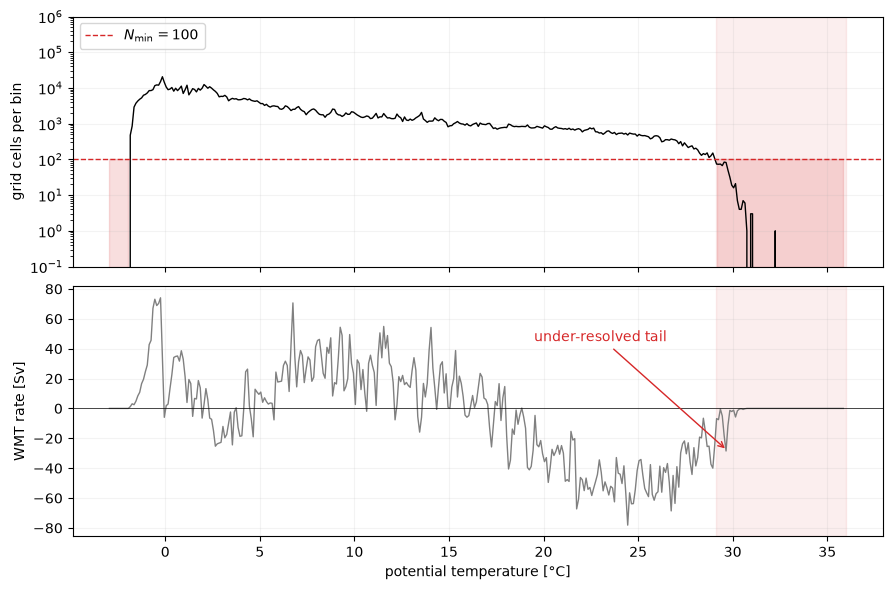

In [4]:
rho0 = 1035.0
Sv_per_kgpers = 1e-6 / rho0
theta = G["thetao_l_target"]
N_min = 100

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].semilogy(theta, N_cells, color="k", lw=1)
axes[0].axhline(N_min, color="C3", ls="--", lw=1, label=f"$N_{{\\min}} = {N_min}$")
axes[0].fill_between(
    theta, 1e-1, N_min, where=N_cells < N_min, color="C3", alpha=0.15, step="mid"
)
axes[0].set_ylim(1e-1, 1e6)
axes[0].set_ylabel("grid cells per bin")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.15)

axes[1].plot(
    theta,
    G["material_transformation"] * Sv_per_kgpers,
    color="grey",
    lw=1,
)
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].set_ylabel("WMT rate [Sv]")
axes[1].set_xlabel(r"potential temperature [$\degree$C]")
axes[1].grid(True, alpha=0.15)

for ax in axes:
    ax.axvspan(29.1, 36.0, color="C3", alpha=0.08)
axes[1].annotate(
    "under-resolved tail",
    xy=(29.7, -28.0),
    xytext=(19.5, 45.0),
    arrowprops=dict(arrowstyle="->", color="C3"),
    color="C3",
)
plt.tight_layout()

## Masking the under-resolved bins

Passing `N_min` to `integrate_transformations` masks every bin whose census falls below the
threshold. Bins that survive are untouched — masking only ever removes bins, it never
changes a retained value.

In [5]:
with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    G_masked = wmt.integrate_transformations(
        "heat", bins=bins, group_processes=True, N_min=N_min
    )

with ProgressBar():
    G_masked = G_masked.mean("time").load()

n_masked = int(np.isnan(G_masked["material_transformation"]).sum())
print(f"{n_masked} of {theta.size} bins masked at N_min = {N_min}")

[                                        ] | 0% Completed | 63.75 us

[#####                                   ] | 12% Completed | 114.96 ms

[############################            ] | 70% Completed | 234.64 ms

[########################################] | 100% Completed | 345.19 ms

79 of 389 bins masked at N_min = 100


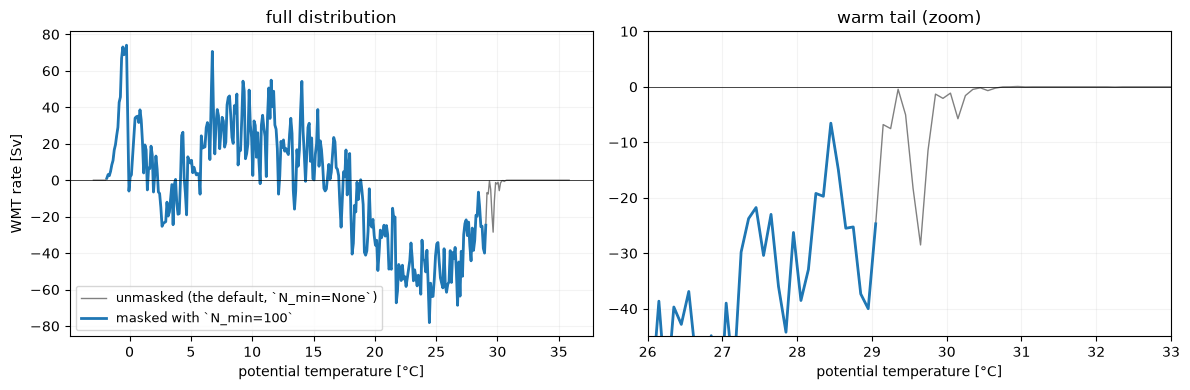

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    ax.plot(
        theta,
        G["material_transformation"] * Sv_per_kgpers,
        color="grey",
        lw=1,
        label="unmasked (the default, `N_min=None`)",
    )
    ax.plot(
        theta,
        G_masked["material_transformation"] * Sv_per_kgpers,
        color="C0",
        lw=2,
        label=f"masked with `N_min={N_min}`",
    )
    ax.axhline(0.0, color="k", lw=0.5)
    ax.set_xlabel(r"potential temperature [$\degree$C]")
    ax.grid(True, alpha=0.15)

axes[0].set_ylabel("WMT rate [Sv]")
axes[0].legend(loc="lower left", fontsize=9)
axes[0].set_title("full distribution")

axes[1].set_xlim(26.0, 33.0)
axes[1].set_ylim(-45.0, 10.0)
axes[1].set_title("warm tail (zoom)")
plt.tight_layout()

## Choosing `N_min`

There is no universally correct threshold — it depends on the grid, the bin width, and how
much of the domain you have masked out. The census is the thing to look at: plot
`count_cells_per_bin` for your bins and pick a value that cuts off the tails where the count
collapses by orders of magnitude, as it does above 29 °C here. Note that halving the bin
width roughly halves the count in every bin, so `N_min` has to be revisited whenever `bins`
changes.

Two things worth keeping in mind:

- A large count is necessary but not sufficient for a converged transformation rate. `N_min`
  removes bins that are obviously under-resolved; it does not certify the rest.
- Setting `N_min` on the constructor makes it the default for every subsequent call, which is
  usually what you want in an analysis script (a per-call `N_min` still overrides it).

In [7]:
wmt_masked = xwmt.WaterMassTransformations(grid, simple_budgets, N_min=N_min)

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    G_default_masked = wmt_masked.integrate_transformations(
        "heat", bins=bins, group_processes=True
    ).mean("time")

with ProgressBar():
    G_default_masked = G_default_masked.load()

# Same result as passing `N_min` explicitly above.
np.array_equal(
    np.isnan(G_default_masked["material_transformation"].values),
    np.isnan(G_masked["material_transformation"].values),
)

[                                        ] | 0% Completed | 79.50 us

[#####                                   ] | 12% Completed | 111.36 ms

[####################                    ] | 51% Completed | 220.26 ms

[########################################] | 100% Completed | 323.13 ms

True

### Column-wise transformations

`map_transformations` accepts `N_min` too, but there the census is taken **within each grid
column** rather than over the whole domain, so a useful threshold is a small number bounded
by the number of vertical levels — not the hundreds or thousands that make sense for a
domain-wide integral. Use `count_cells_per_bin(..., integrate=False)` to see the column-wise
counts.

[                                        ] | 0% Completed | 66.17 us

[########################################] | 100% Completed | 111.09 ms

[                                        ] | 0% Completed | 100.00 us

[##########                              ] | 27% Completed | 111.77 ms

[##########                              ] | 27% Completed | 213.18 ms

...

[##############                          ] | 37% Completed | 448.85 ms

[####################                    ] | 50% Completed | 559.94 ms

[##############################          ] | 77% Completed | 672.56 ms

[#################################       ] | 83% Completed | 773.79 ms

[########################################] | 100% Completed | 874.89 ms

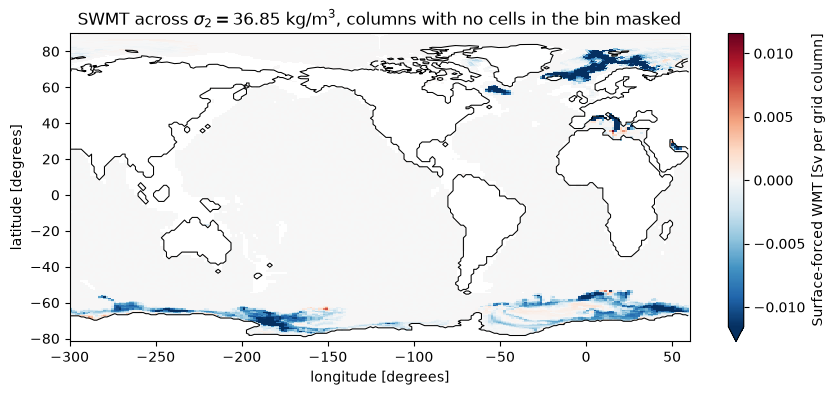

In [8]:
sigma2_lev = 36.85
sigma2_bins = np.arange(28.0, 38.0, 0.2)

with warnings.catch_warnings():
    warnings.simplefilter(action="ignore", category=FutureWarning)
    column_counts = wmt.count_cells_per_bin(
        "sigma2", bins=sigma2_bins, integrate=False
    ).sel(sigma2_l_target=sigma2_lev, method="nearest")
    G_map = wmt.map_transformations("sigma2", bins=sigma2_bins, N_min=1).sel(
        sigma2_l_target=sigma2_lev, method="nearest"
    )

with ProgressBar():
    column_counts = column_counts.mean("time").load()
    G_map = G_map.mean("time").load()

plt.figure(figsize=(10, 4))
pc = (G_map["surface_exchange_flux"] * Sv_per_kgpers).plot(
    x="geolon", y="geolat", robust=True
)
(G_map.wet == 0).plot.contour(
    levels=[0], colors="k", x="geolon", y="geolat", linewidths=0.75
)
pc.colorbar.set_label("Surface-forced WMT [Sv per grid column]")
plt.xlabel("longitude [degrees]")
plt.ylabel("latitude [degrees]")
plt.title(
    rf"SWMT across $\sigma_{{2}} = {sigma2_lev}$ kg/m$^{{3}}$, "
    rf"columns with no cells in the bin masked"
);